# MLP untuk Intrusion Detection — CSE-CIC-IDS2018

**Model:** MLP standar (Multi-Layer Perceptron) — input langsung dari 38 fitur

| Komponen | Nilai |
|---|---|
| Input | 38 fitur (dari preprocessing) |
| Arsitektur | 38 → 256 → 128 → 64 → 1 |
| Holdout | Infiltration |
| Target F1 | ≥ 85% |
| Target FPR | ≤ 2% |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Sel 1 — Setup

In [2]:
!pip install tensorflow --quiet

import os, gc, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, auc, roc_auc_score
)

tf.random.set_seed(42)
np.random.seed(42)

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
RANDOM_STATE = 42

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


---
## Sel 2 — Load Data

In [3]:
print('Memuat dataset_split.joblib...')
data = joblib.load(os.path.join(dataset_path, 'dataset_split.joblib'))

X_train = data['X_train'].astype('float32')
X_val   = data['X_val'].astype('float32')
X_test  = data['X_test'].astype('float32')
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']

lbl_train = data['label_train']
lbl_val   = data['label_val']
lbl_test  = data['label_test']

features   = data['features']
n_features = data['n_features']
CW         = data['class_weights']

del data
gc.collect()

ZERO_DAY_LABEL = 'Infiltration'

mask_no_inf_train = (lbl_train != ZERO_DAY_LABEL)
mask_no_inf_val   = (lbl_val   != ZERO_DAY_LABEL)

X_mlp_train = X_train[mask_no_inf_train]
y_mlp_train = y_train[mask_no_inf_train]
X_mlp_val   = X_val[mask_no_inf_val]
y_mlp_val   = y_val[mask_no_inf_val]

mask_infiltration_test = (lbl_test == ZERO_DAY_LABEL)
X_infiltration_test   = X_test[mask_infiltration_test].astype('float32')

print(f'Fitur              : {n_features}')
print(f'Train (tanpa Inf)  : {X_mlp_train.shape[0]:,}')
print(f'Val   (tanpa Inf)  : {X_mlp_val.shape[0]:,}')
print(f'Test               : {X_test.shape[0]:,}')
print(f'Infiltration test  : {X_infiltration_test.shape[0]:,}')
print(f'CW                 : {CW}')

inf_train = (lbl_train == ZERO_DAY_LABEL).sum()
print(f'\nInfiltrasi di train: {inf_train:,} (disembunyikan)')
print('\nDistribusi test:')
for lbl, cnt in sorted(zip(*np.unique(lbl_test, return_counts=True)),
                       key=lambda x: -x[1]):
    print(f'  {lbl:<35} {cnt:>7,}')

Memuat dataset_split.joblib...
Fitur              : 38
Train (tanpa Inf)  : 8,099,910
Val   (tanpa Inf)  : 1,735,731
Test               : 1,759,848
Infiltration test  : 24,180
CW                 : {0: 0.6528867291008229, 1: 2.135197518256373}

Infiltrasi di train: 112,760 (disembunyikan)

Distribusi test:
  Benign                              1,347,722
  DDOS attack-HOIC                    102,902
  DDoS attacks-LOIC-HTTP               86,428
  DoS attacks-Hulk                     69,287
  Bot                                  42,928
  FTP-BruteForce                       29,004
  SSH-Bruteforce                       28,139
  Infiltration                         24,180
  DoS attacks-SlowHTTPTest             20,983
  DoS attacks-GoldenEye                 6,227
  DoS attacks-Slowloris                 1,648
  DDOS attack-LOIC-UDP                    260
  Brute Force -Web                         92
  Brute Force -XSS                         35
  SQL Injection                            13


---
## Sel 3 — Arsitektur MLP

In [4]:
def build_mlp(input_dim=38):
    inp = layers.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out, name='MLP_IDS')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc', curve='PR')]
    )
    return model

mlp = build_mlp(input_dim=n_features)
mlp.summary()


Model: "MLP_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,097 (766.00 KB)

 Trainable params: 194,305 (759.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

---
## Sel 4 — Training MLP

In [5]:
cb_early = callbacks.EarlyStopping(
    monitor='val_auc', patience=5,
    restore_best_weights=True, mode='max', verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_auc', factor=0.3, patience=3,
    min_lr=1e-6, mode='max', verbose=1
)

print(f'Training MLP pada {X_mlp_train.shape[0]:,} sampel (tanpa Infiltration)...')
print(f'Class weights: {CW}')

history = mlp.fit(
    X_mlp_train, y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=50,
    batch_size=4096,
    class_weight=CW,
    callbacks=[cb_early, cb_lr],
    verbose=1
)

mlp.save(os.path.join(dataset_path, 'mlp_model_final.keras'))
print('Model tersimpan.')

Training MLP pada 8,099,910 sampel (tanpa Infiltration)...
Class weights: {0: 0.6528867291008229, 1: 2.135197518256373}
Epoch 1/50
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 429s 211ms/step - accuracy: 0.9938 - auc: 0.9955 - loss: 0.0174 - val_accuracy: 0.9968 - val_auc: 0.9975 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 2/50
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 410s 207ms/step - accuracy: 0.9967 - auc: 0.9971 - loss: 0.0103 - val_accuracy: 0.9975 - val_auc: 0.9960 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 3/50
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 440s 206ms/step - accuracy: 0.9972 - auc: 0.9977 - loss: 0.0088 - val_accuracy: 0.9975 - val_auc: 0.9988 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 4/50
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 409s 207ms/step - accuracy: 0.9977 - auc: 0.9984 - loss: 0.0070 - val_accuracy: 0.9970 - val_auc: 0.9992 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 5/50
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 411s 208ms/step - accuracy: 0.9981 - auc: 0.9989 - loss: 0.0055 - val_accuracy

---
## Sel 5 — Kurva Konvergensi

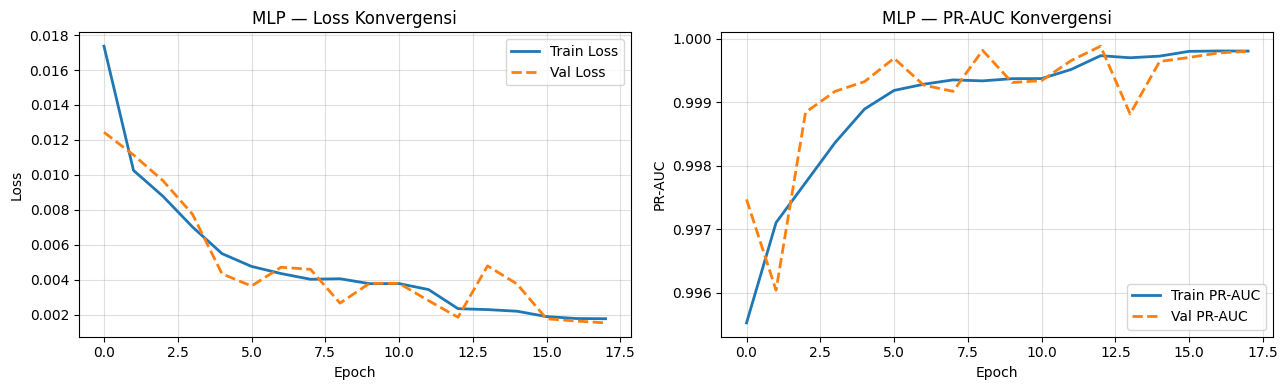

Best Val PR-AUC : 0.9999
Best Val Loss   : 0.0015


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   lw=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('MLP — Loss Konvergensi')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(history.history['auc'],     label='Train PR-AUC', lw=2)
axes[1].plot(history.history['val_auc'], label='Val PR-AUC',   lw=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PR-AUC')
axes[1].set_title('MLP — PR-AUC Konvergensi')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(f'Best Val PR-AUC : {max(history.history["val_auc"]):.4f}')
print(f'Best Val Loss   : {min(history.history["val_loss"]):.4f}')

---
## Sel 6 — Threshold Tuning

Prediksi probabilitas pada test set...
Threshold optimal : 0.87
  F1  : 96.8817%
  FPR : 0.0187%


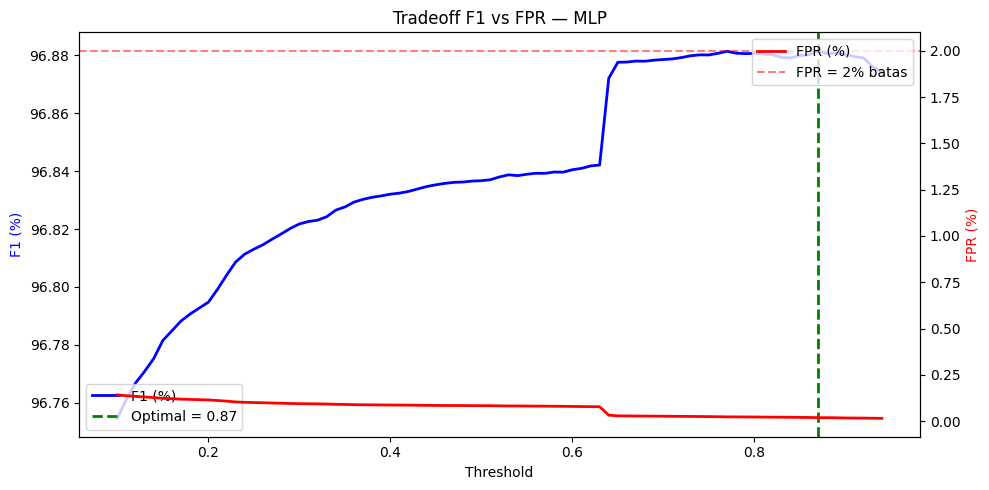

In [7]:
print('Prediksi probabilitas pada test set...')
y_probs = mlp.predict(X_test, batch_size=4096, verbose=0).ravel()

thresholds_sweep = np.arange(0.1, 0.95, 0.01)
results_thr = []
for thr in thresholds_sweep:
    y_p = (y_probs > thr).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, y_p).ravel()
    fpr_ = fp_ / (fp_ + tn_) * 100
    f1_  = f1_score(y_test, y_p) * 100
    results_thr.append({'threshold': thr, 'F1': f1_, 'FPR': fpr_})

df_thr = pd.DataFrame(results_thr)
valid  = df_thr[df_thr['FPR'] <= 2.0]

if len(valid) > 0:
    best = valid.loc[valid['F1'].idxmax()]
    THRESHOLD = best['threshold']
    print(f'Threshold optimal : {THRESHOLD:.2f}')
    print(f'  F1  : {best["F1"]:.4f}%')
    print(f'  FPR : {best["FPR"]:.4f}%')
else:
    THRESHOLD = 0.5
    print('Tidak ada threshold FPR<=2% — pakai 0.5')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_thr['threshold'], df_thr['F1'],  'b-', lw=2, label='F1 (%)')
ax2.plot(df_thr['threshold'], df_thr['FPR'], 'r-', lw=2, label='FPR (%)')
ax2.axhline(y=2.0, color='red', linestyle='--', alpha=0.5, label='FPR = 2% batas')
ax1.axvline(x=THRESHOLD, color='green', linestyle='--', lw=2,
            label=f'Optimal = {THRESHOLD:.2f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('F1 (%)', color='blue')
ax2.set_ylabel('FPR (%)', color='red')
ax1.set_title('Tradeoff F1 vs FPR — MLP')
ax1.legend(loc='lower left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

---
## Sel 7 — Evaluasi Binary

 EVALUASI MLP — TEST SET
Accuracy                       98.5828%
F1-Score (Attack)              96.8817%
False Positive Rate (FPR)      0.0187%
Detection Rate (Recall)        94.0094%
True Positive                  387,437
False Negative                 24,689
False Positive                 252
True Negative                  1,347,470
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9820    0.9998    0.9908   1347722
      Attack     0.9993    0.9401    0.9688    412126

    accuracy                         0.9858   1759848
   macro avg     0.9907    0.9700    0.9798   1759848
weighted avg     0.9861    0.9858    0.9857   1759848

Target F1 >= 85%  : 96.88%   — TERCAPAI
Target FPR <= 2%  : 0.0187% — TERCAPAI


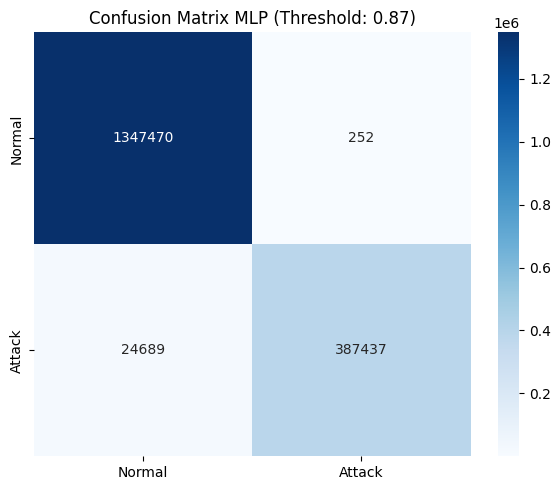

In [8]:
y_pred = (y_probs > THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_  = fp / (fp + tn) * 100
tpr_  = tp / (tp + fn) * 100
f1_   = f1_score(y_test, y_pred) * 100
acc_  = (tp + tn) / len(y_test) * 100

print('=' * 55)
print(' EVALUASI MLP — TEST SET')
print('=' * 55)
print(f'{"Accuracy":<30} {acc_:.4f}%')
print(f'{"F1-Score (Attack)":<30} {f1_:.4f}%')
print(f'{"False Positive Rate (FPR)":<30} {fpr_:.4f}%')
print(f'{"Detection Rate (Recall)":<30} {tpr_:.4f}%')
print(f'{"True Positive":<30} {tp:,}')
print(f'{"False Negative":<30} {fn:,}')
print(f'{"False Positive":<30} {fp:,}')
print(f'{"True Negative":<30} {tn:,}')
print('-' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Normal', 'Attack'], digits=4))
f1_ok  = 'TERCAPAI' if f1_  >= 85 else 'BELUM'
fpr_ok = 'TERCAPAI' if fpr_ <=  2 else 'BELUM'
print(f'Target F1 >= 85%  : {f1_:.2f}%   — {f1_ok}')
print(f'Target FPR <= 2%  : {fpr_:.4f}% — {fpr_ok}')

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title(f'Confusion Matrix MLP (Threshold: {THRESHOLD:.2f})')
plt.tight_layout(); plt.show()

---
## Sel 8 — PR-AUC dan ROC-AUC

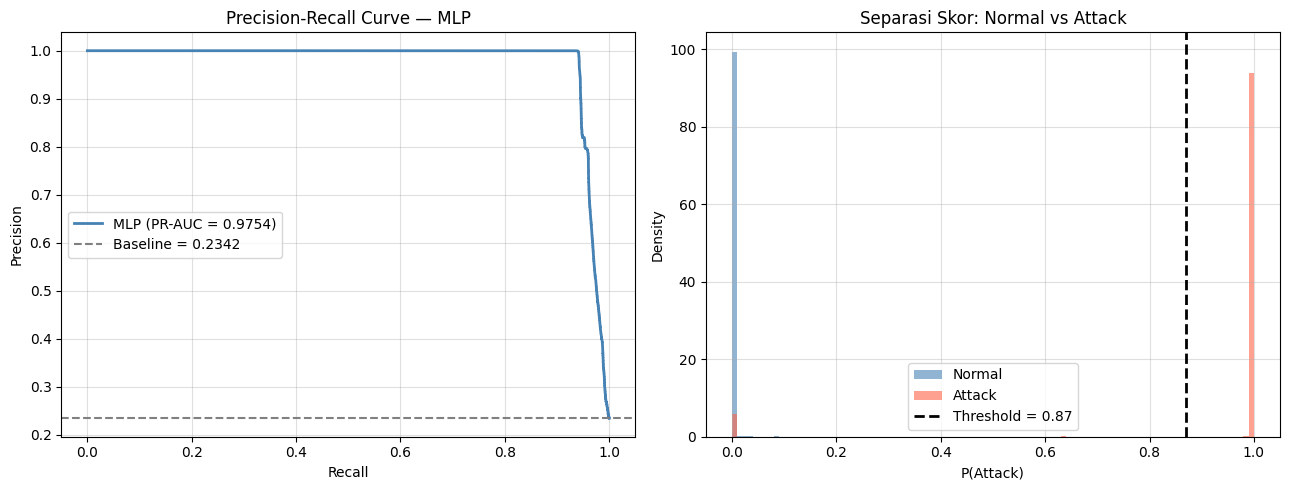

PR-AUC  : 0.9754
ROC-AUC : 0.9815


In [9]:
precision_, recall_, _ = precision_recall_curve(y_test, y_probs)
pr_auc  = auc(recall_, precision_)
roc_auc = roc_auc_score(y_test, y_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

baseline = y_test.mean()
axes[0].plot(recall_, precision_, color='steelblue', lw=2,
             label=f'MLP (PR-AUC = {pr_auc:.4f})')
axes[0].axhline(y=baseline, color='gray', linestyle='--',
                label=f'Baseline = {baseline:.4f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — MLP')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].hist(y_probs[y_test==0], bins=100, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[1].hist(y_probs[y_test==1], bins=100, alpha=0.6,
             color='tomato', label='Attack', density=True)
axes[1].axvline(THRESHOLD, color='black', lw=2, linestyle='--',
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_xlabel('P(Attack)'); axes[1].set_ylabel('Density')
axes[1].set_title('Separasi Skor: Normal vs Attack')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(f'PR-AUC  : {pr_auc:.4f}')
print(f'ROC-AUC : {roc_auc:.4f}')

---
## Sel 9 — Evaluasi Per Jenis Serangan

Detection Rate per Jenis Serangan — MLP (Holdout: Infiltration):
             Attack Type  Sampel  Terdeteksi Detection Rate (%) Mean P(Attack) Zero-Day
                     Bot   42928       42881               99.9         0.9985         
        Brute Force -Web      92          35               38.0         0.4777         
        Brute Force -XSS      35          20               57.1         0.6538         
        DDOS attack-HOIC  102902      102902              100.0         1.0000         
    DDOS attack-LOIC-UDP     260         260              100.0         1.0000         
  DDoS attacks-LOIC-HTTP   86428       86372               99.9         0.9995         
   DoS attacks-GoldenEye    6227        6223               99.9         0.9996         
        DoS attacks-Hulk   69287       69287              100.0         1.0000         
DoS attacks-SlowHTTPTest   20983       20983              100.0         1.0000         
   DoS attacks-Slowloris    1648        1293           

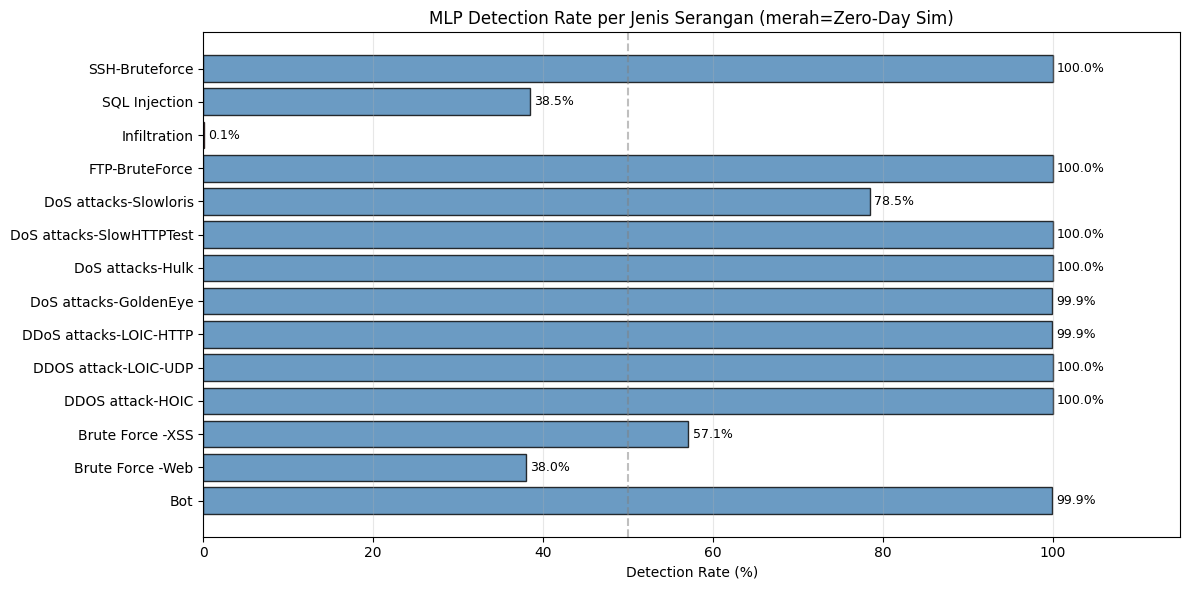

In [10]:
rows = []
for lbl in sorted(np.unique(lbl_test[y_test == 1])):
    mask = (lbl_test == lbl)
    if mask.sum() == 0: continue
    prob_lbl = y_probs[mask]
    pred_lbl = (prob_lbl > THRESHOLD).astype(int)
    n_t = mask.sum(); n_d = pred_lbl.sum()
    is_zd = 'YES' if lbl == ZERO_DAY_LABEL else ''
    rows.append({
        'Attack Type': lbl, 'Sampel': n_t, 'Terdeteksi': n_d,
        'Detection Rate (%)': f'{n_d/n_t*100:.1f}',
        'Mean P(Attack)': f'{prob_lbl.mean():.4f}',
        'Zero-Day': is_zd
    })

df_atk = pd.DataFrame(rows)
print('Detection Rate per Jenis Serangan — MLP (Holdout: Infiltration):')
print(df_atk.to_string(index=False))

probs_inf = mlp.predict(X_infiltration_test, batch_size=4096, verbose=0).ravel()
pred_inf  = (probs_inf > THRESHOLD).astype(int)
dr_inf    = pred_inf.mean() * 100

print(f'\n{"="*55}')
print(f' SIMULASI ZERO-DAY: INFILTRATION (MLP)')
print(f'{"="*55}')
print(f'Sampel Infiltration test  : {len(pred_inf):,}')
print(f'Terdeteksi                : {pred_inf.sum():,} ({dr_inf:.2f}%)')
print(f'Mean P(Attack)            : {probs_inf.mean():.4f}')
print(f'Mean P(Attack) Normal     : {y_probs[y_test==0].mean():.4f}')
print(f'Threshold                 : {THRESHOLD:.2f}')

fig, ax = plt.subplots(figsize=(12, 6))
det_rates = [float(r['Detection Rate (%)']) for r in rows]
bar_colors = ['crimson' if r['Zero-Day'] == 'YES' else 'steelblue' for r in rows]
bars = ax.barh([r['Attack Type'] for r in rows], det_rates,
               color=bar_colors, alpha=0.8, edgecolor='black')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Detection Rate (%)')
ax.set_title('MLP Detection Rate per Jenis Serangan (merah=Zero-Day Sim)')
for bar, val in zip(bars, det_rates):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 115); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

---
## Sel 10 — Ringkasan Final dan Simpan

In [11]:
print('=' * 55)
print(' RINGKASAN HASIL MLP — CSE-CIC-IDS2018')
print('=' * 55)
print(f'\n--- Konfigurasi ---')
print(f'  Arsitektur  : 38 -> 512 -> 256 -> 128 -> 64 -> 1')
print(f'  Input       : {n_features} fitur ')
print(f'  Holdout     : Infiltration ')
print(f'  Threshold   : {THRESHOLD:.2f}')
print(f'\n--- Performa Deteksi ---')
print(f'  {"Accuracy":<30} {acc_:.4f}%')
print(f'  {"F1-Score (Attack)":<30} {f1_:.4f}%')
print(f'  {"False Positive Rate":<30} {fpr_:.4f}%')
print(f'  {"Detection Rate (Recall)":<30} {tpr_:.4f}%')
print(f'  {"PR-AUC":<30} {pr_auc:.4f}')
print(f'  {"ROC-AUC":<30} {roc_auc:.4f}')
f1_ok  = 'TERCAPAI' if f1_  >= 85 else 'BELUM'
fpr_ok = 'TERCAPAI' if fpr_ <=  2 else 'BELUM'
print(f'\n--- Target ---')
print(f'  F1 >= 85%  : {f1_:.2f}%   — {f1_ok}')
print(f'  FPR <= 2%  : {fpr_:.4f}% — {fpr_ok}')
print(f'\n--- Zero-Day (Infiltration Holdout) ---')
print(f'  Detection Rate : {dr_inf:.2f}%')
print(f'  Catatan        : MLP tidak pernah lihat Infiltration')

results_mlp = {
    'model'                  : 'MLP Standar',
    'f1'                     : f1_,
    'fpr'                    : fpr_,
    'recall'                 : tpr_,
    'accuracy'               : acc_,
    'pr_auc'                 : pr_auc,
    'roc_auc'                : roc_auc,
    'threshold'              : THRESHOLD,
    'zero_day_detection_rate': dr_inf,
    'zero_day_label'         : ZERO_DAY_LABEL
}
joblib.dump(results_mlp, os.path.join(dataset_path, 'results_mlp.joblib'))
mlp.save(os.path.join(dataset_path, 'mlp_model_final.keras'))
print('\n--- File Tersimpan ---')
print(f'  v mlp_model_final.keras')
print(f'  v results_mlp.joblib')

 RINGKASAN HASIL MLP — CSE-CIC-IDS2018

--- Konfigurasi ---
  Arsitektur  : 38 -> 512 -> 256 -> 128 -> 64 -> 1
  Input       : 38 fitur 
  Holdout     : Infiltration 
  Threshold   : 0.87

--- Performa Deteksi ---
  Accuracy                       98.5828%
  F1-Score (Attack)              96.8817%
  False Positive Rate            0.0187%
  Detection Rate (Recall)        94.0094%
  PR-AUC                         0.9754
  ROC-AUC                        0.9815

--- Target ---
  F1 >= 85%  : 96.88%   — TERCAPAI
  FPR <= 2%  : 0.0187% — TERCAPAI

--- Zero-Day (Infiltration Holdout) ---
  Detection Rate : 0.14%
  Catatan        : MLP tidak pernah lihat Infiltration

--- File Tersimpan ---
  v mlp_model_final.keras
  v results_mlp.joblib
